In [7]:
import random
import pprint
import sys
import time
import numpy as np
from optparse import OptionParser
import pickle
import math
import cv2
import copy
from matplotlib import pyplot as plt
import tensorflow as tf
tf.config.run_functions_eagerly(True)

import pandas as pd
import os

from sklearn.metrics import average_precision_score

from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.layers import Flatten, Dense, Input, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.initializers import Initializer
from tensorflow.keras.regularizers import Regularizer
from tensorflow.keras.utils import get_file
from tensorflow.python.keras.utils import layer_utils
from tensorflow.python.keras.utils import generic_utils
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.layers import Layer, InputSpec
from tensorflow.keras.optimizers import Adam

In [8]:
def get_data(annotation_path):
    all_data = []
    class_count = {}
    class_mapping = {}
    image_data = {}

    # Open the annotation file
    with open(annotation_path, 'r') as f:
        for line in f:
            # Split line by commas
            line_split = line.strip().split(',')

            # Extract fields
            img_file = line_split[0]
            xmin = int(line_split[1])
            ymin = int(line_split[2])
            xmax = int(line_split[3])
            ymax = int(line_split[4])
            local_class = line_split[5]

            # Initialize an entry for each image if it doesn’t already exist
            if img_file not in image_data:
                image_data[img_file] = {
                    'filepath': img_file,
                    'bboxes': [],
                    'overall_label': 'injury_present'  # Default label
                }

            # Append bounding box details for each image
            image_data[img_file]['bboxes'].append({
                'x1': xmin,
                'y1': ymin,
                'x2': xmax,
                'y2': ymax,
                'class': local_class
            })

            # Track class occurrences and mapping
            if local_class not in class_count:
                class_count[local_class] = 1
            else:
                class_count[local_class] += 1

            if local_class not in class_mapping:
                class_mapping[local_class] = len(class_mapping)

    # Convert image_data dict to list for all_data
    all_data = list(image_data.values())
    
    return all_data, class_count, class_mapping

In [9]:
all_data, class_count, class_mapping = get_data(r'annotation.txt')
val_data, class_count, class_mapping = get_data(r'valid_annotation.txt')
test_data, class_count, class_mapping = get_data(r'test_annotation.txt')

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=20,       # Random rotation within 20 degrees
    width_shift_range=0.2,   # Horizontal shift up to 20% of the image width
    height_shift_range=0.2,  # Vertical shift up to 20% of the image height
    shear_range=0.2,         # Shear transformations
    zoom_range=0.2,          # Random zoom
    horizontal_flip=True,    # Randomly flip images horizontally
    fill_mode='nearest'      # Fill in missing pixels after transformations
)

def data_generator(data, class_mapping, batch_size):
    while True:  # Loop forever to generate batches indefinitely
        for i in range(0, len(data), batch_size): 
            batch_images = []
            batch_labels = []
            for item in data[i:i + batch_size]:
                # Load and preprocess each image
                img = tf.keras.preprocessing.image.load_img(item['filepath'], target_size=(224, 224))
                img = tf.keras.preprocessing.image.img_to_array(img) / 255.0  # Normalize the image

                # Apply augmentation
                img = datagen.random_transform(img)  # Apply random transformations
                
                batch_images.append(img)

                # Get the hemorrhage type from the first bounding box
                local_class = item['bboxes'][0]['class']  # Assuming you take the first bounding box class
                label = class_mapping[local_class]  # Get numerical label from mapping
                batch_labels.append(label)

            # Convert the batch_labels to one-hot encoding for multi-class classification
            batch_labels = tf.keras.utils.to_categorical(batch_labels, num_classes=len(class_mapping))

            # Yield the batch of images and labels as numpy arrays
            yield (np.array(batch_images), np.array(batch_labels))

# Example class mapping
class_mapping = {
    'Intraventricular': 0,
    'Subdural': 1,
    'Intraparenchymal': 2,
    'Subarachnoid': 3,
}

In [11]:
from tensorflow.keras import layers, models
import tensorflow as tf

def detection_and_classification_model(num_classes, num_detection_classes):
    # Base model for feature extraction
    base_model = tf.keras.applications.VGG16(input_shape=(224, 224, 3), include_top=False, weights='imagenet', classifier_activation='softmax')
    
    # Detection Head for Faster R-CNN (RPN and ROI Pooling layers)
    x = base_model.output
    rpn_output = layers.Conv2D(512, (3, 3), activation='relu')(x)
    # Add layers specific to detection task here, e.g., ROI Pooling, classification layers for each bounding box
    # Detection Output - bounding boxes and localized classifications
    detection_output = layers.Dense(num_detection_classes, activation='sigmoid', name='detection_output')(rpn_output)

    # Global Classification Head (for whole image classification)
    x_classification = layers.GlobalAveragePooling2D()(x) # Dimensionality reduction 
    x_classification = layers.Dense(1024, activation='relu')(x_classification)
    x_classification = layers.Dropout(0.5)(x_classification)
    classification_output = layers.Dense(len(class_mapping), activation='softmax', name='classification_output')(x_classification)

    # Model with dual outputs
    model = models.Model(inputs=base_model.input, outputs=[classification_output, detection_output])
    return model

In [12]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Assuming 2 classes for overall classification and 3 types of brain injuries for detection
num_classes = 4  # e.g., "no injury" or "injury present"
num_detection_classes = len(class_mapping)  # Number of unique local injury classes

early_stopping = EarlyStopping(
    monitor='val_loss',  # Track validation loss
    patience=3,          # Stop after 5 epochs with no improvement
    restore_best_weights=True
)

# Build and compile the model
model = detection_and_classification_model(num_classes, num_detection_classes)
custom_learning_rate = 0.0001
optimizer = Adam(learning_rate=custom_learning_rate)  # Use the imported Adam optimizer
model.compile(
    optimizer=optimizer,
    loss={
        'classification_output': 'categorical_crossentropy',
        'detection_output': 'mse'
    },
    metrics={
        'classification_output': ['accuracy'],
        'detection_output': ['mse']
    }
)

In [13]:

train_gen = data_generator(all_data, class_mapping, batch_size=32)
val_gen = data_generator(val_data, class_mapping, batch_size=32)

# Training loop
history = model.fit(
    train_gen,
    steps_per_epoch=len(all_data) // 16,
    validation_data=val_gen,
    validation_steps=len(val_data) // 16,
    epochs=10,
    callbacks=[early_stopping]
)


Epoch 1/10


c:\Python311\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


1/2 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - classification_output_accuracy: 0.2500 - loss: 1.6690

c:\Python311\Lib\site-packages\keras\src\optimizers\base_optimizer.py:664: UserWarning: Gradients do not exist for variables ['kernel', 'bias', 'kernel', 'bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - classification_output_accuracy: 0.2578 - loss: 1.6120 

KeyboardInterrupt: 

In [ ]:
'''from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Adjusted batch size and epochs
batch_size = 64
epochs = 10

# Data generators with updated batch size
train_gen = data_generator(all_data, class_mapping, batch_size)
val_gen = data_generator(val_data, class_mapping, batch_size)

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Learning rate scheduler for better convergence
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

# Train the model with updated callbacks and settings
history = model.fit(
    train_gen,
    steps_per_epoch=len(all_data) // batch_size,
    validation_data=val_gen,
    validation_steps=len(val_data) // batch_size,
    epochs=epochs,
    callbacks=[early_stopping, reduce_lr]
)
'''

Epoch 1/10
    106/Unknown 1420s 13s/step - accuracy: 0.2603 - loss: 1.5008

KeyboardInterrupt: 

In [ ]:
# Evaluate the model on the test data
test_gen = data_generator(test_data, class_mapping, batch_size=32)

# Evaluate the model
results = model.evaluate(
    test_gen,
    steps=100,  # Adjust based on the test dataset size
    verbose=1
)

# Print the results list to debug
print("Results from model.evaluate():", results)

# Unpack the results based on their length
if len(results) == 2:
    # Case 1: Only one output (classification)
    test_loss = results[0]  # Total loss
    test_classification_accuracy = results[1]  # Accuracy for classification
    print("Evaluation Results:")
    print(f"Test Loss: {test_loss}")
    print(f"Classification Accuracy: {test_classification_accuracy}")
elif len(results) == 5:
    # Case 2: Two outputs (classification and detection)
    test_loss = results[0]  # Total loss
    test_classification_loss = results[1]  # Loss for classification
    test_detection_loss = results[2]  # Loss for detection
    test_classification_accuracy = results[3]  # Accuracy for classification
    test_detection_mse = results[4]  # MSE for detection
    print("Evaluation Results:")
    print(f"Test Loss: {test_loss}")
    print(f"Classification Loss: {test_classification_loss}")
    print(f"Detection Loss: {test_detection_loss}")
    print(f"Classification Accuracy: {test_classification_accuracy}")
    print(f"Detection Mean Squared Error: {test_detection_mse}")
else:
    print("Unexpected number of results from model.evaluate(). Please debug the model.")

100/100 ━━━━━━━━━━━━━━━━━━━━ 99s 988ms/step - classification_output_accuracy: 0.1250 - loss: 1.5647
Results from model.evaluate(): [1.564651608467102, 0.125]
Evaluation Results:
Test Loss: 1.564651608467102
Classification Accuracy: 0.125


In [ ]:
# Load a sample image
sample_image = tf.keras.preprocessing.image.load_img(r'test/ID_0027df23b_png_jpg.rf.78a4fefadb07409a5671806d177c2168.jpg', target_size=(224, 224))
sample_image = tf.keras.preprocessing.image.img_to_array(sample_image) / 255.0
sample_image = np.expand_dims(sample_image, axis=0)  # Add batch dimension

# Predict
classification_pred, detection_pred = model.predict(sample_image)

# Process predictions
print("Classification Prediction:", classification_pred)  # Injury presence prediction
print("Detection Prediction:", detection_pred)            # Bounding box and injury type predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
Classification Prediction: [[0.25103307 0.31724894 0.27393806 0.15777998]]
Detection Prediction: [[[[0.4893351  0.4977869  0.61654496 0.67940414]
   [0.49026832 0.50377774 0.6111815  0.6595732 ]
   [0.48942125 0.4970635  0.61069554 0.6490854 ]
   [0.47668332 0.5058031  0.60970587 0.64202714]
   [0.45853025 0.5053542  0.60803014 0.6553782 ]]

  [[0.4865249  0.5077193  0.59949833 0.6683006 ]
   [0.48169872 0.50644153 0.5835233  0.6414734 ]
   [0.4816755  0.5031333  0.57780784 0.6351644 ]
   [0.47216353 0.5069464  0.5772602  0.62648743]
   [0.44861165 0.51535964 0.573423   0.6332692 ]]

  [[0.48142517 0.5121696  0.5941767  0.6639174 ]
   [0.47583848 0.51519173 0.56922287 0.63698894]
   [0.4812062  0.5166529  0.5656471  0.63437593]
   [0.48150235 0.5194705  0.5665145  0.63772833]
   [0.44898665 0.51755786 0.5638041  0.63860613]]

  [[0.4808477  0.51011485 0.5929574  0.65960974]
   [0.47898862 0.51734227 0.5717552  0.63144714]
   [0.48478755 0.5183709 

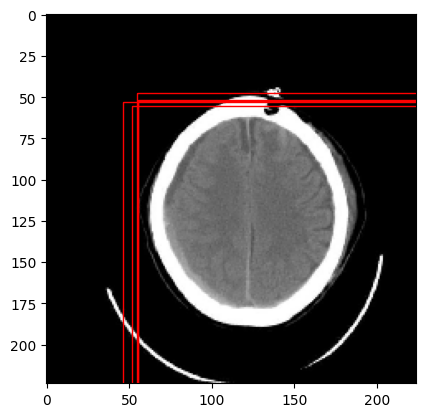

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Define image dimensions (should match the input size used in the model)
img_width, img_height = 300, 300  # Replace with the actual dimensions of your input image

# Load and prepare the image for visualization
img = tf.keras.preprocessing.image.array_to_img(sample_image[0])  # Remove batch dimension

# Create a plot
fig, ax = plt.subplots(1)
ax.imshow(img)

# Draw bounding boxes
for bbox in detection_pred[0][0]:  # Adjust if needed
    x_center, y_center, width, height = bbox
    x_min = (x_center - width / 2) * img_width  # Convert normalized x_center to pixel coordinates
    y_min = (y_center - height / 2) * img_height  # Convert normalized y_center to pixel coordinates
    rect = patches.Rectangle(
        (x_min, y_min), 
        width * img_width,  # Convert normalized width to pixel coordinates
        height * img_height,  # Convert normalized height to pixel coordinates
        linewidth=1, 
        edgecolor='r', 
        facecolor='none'
    )
    ax.add_patch(rect)

# Display the image with bounding boxes
plt.show()